# Lecture 2: Bayesian Inference

## Section 1: How much of the Eart is covered in water?

Well, imagine that we didn't have a satellite picture of the earth and, instead, alll we had was data about where meteors landed: Either (1) water or (2) land. 

We'd end up with a dataset like: ***LLWWLWLWWW***

### How should we use this sample?

How can we produce a summary of this? Given this sample, how should we represent uncertainty in sampling? 

## Bayesian Inference in a Nutshell:

For each possible explanation of the data, let's count **all the ways the data can hapen**. Those explanations that have more ways to produce the data are more plausible!

### Let's leave the Earth for a moment and talk about marbles 

Imagine we had a big with 4 marbles. They can be either blue or white. Now imagine that you are sampling **3 marbles from this bag with replacement**. 

You might have samles like: BWB, WWW, BBW, etc. etc. 

**Our underlying goal is to guess the true distribution of blue and white marbles in the bag**. How do we do this in the Bayesian way? 


#### Reasoning the Bayes way:

Let's start by assuming some underlying true distribution of the data. E.g:

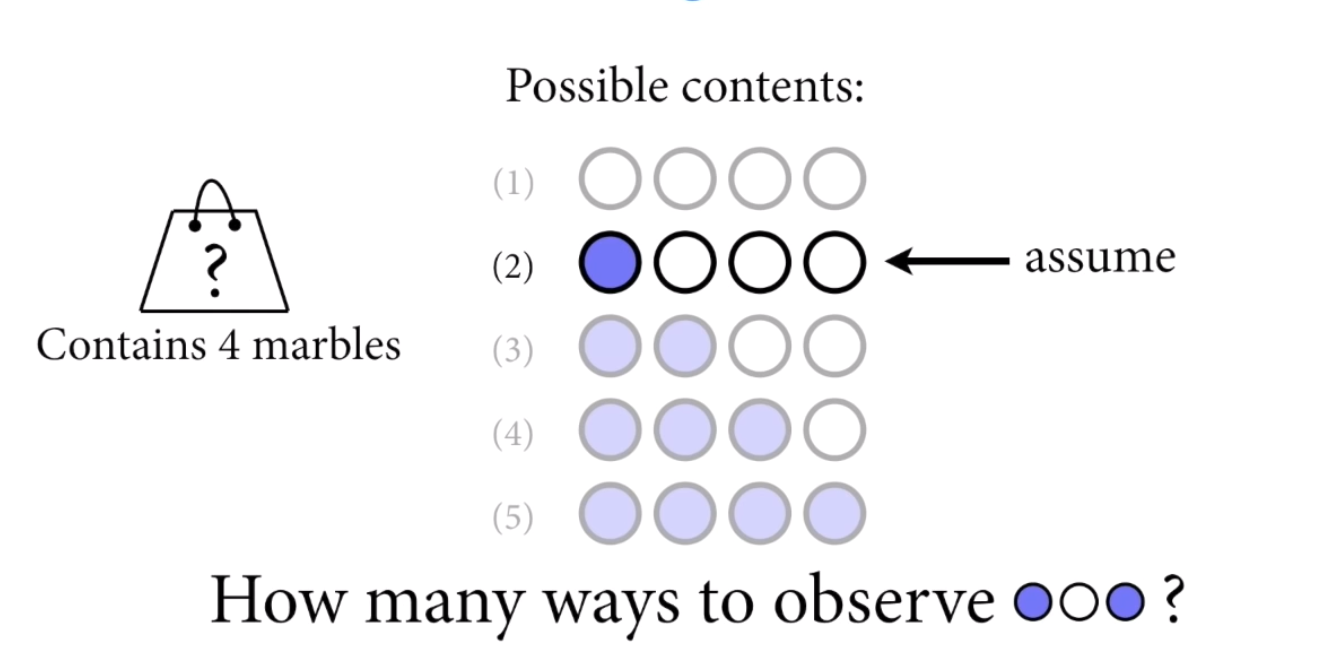

From this aproach, we can then construct the "garden of forking paths" in which we can graphically map out how many ossible ways we have of getting the observed data distribution. 

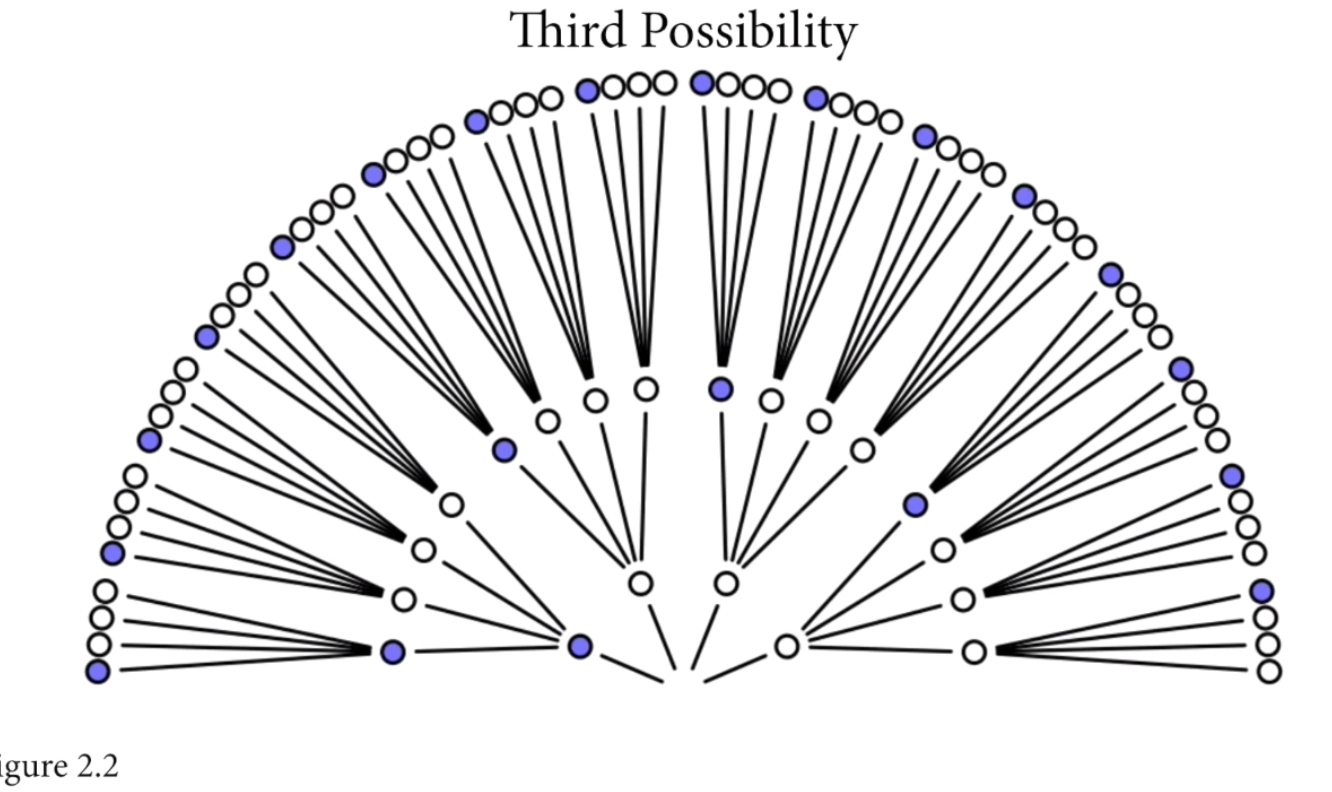

We can, of course, repeat this exercise with all possible assumptions of the underlying true distribution of blue and white marbles.

***Lesson:Things that can happen more ways are more plausible*** (The "Unglamorous Basis of Applied Probability")

In [4]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc3 as pm
import scipy.stats as stats

In [5]:
%config InlineBackend.figure_format = 'retina'
RANDOM_SEED = 8927
np.random.seed(RANDOM_SEED)
az.style.use("arviz-darkgrid")

#### Code 2.1

Note of course that: For each number of ways an outcome can occur, we **normalize** its plausability/probability by dividing by the total number of counts. So, for the following image, we have the subsequent calculation: 


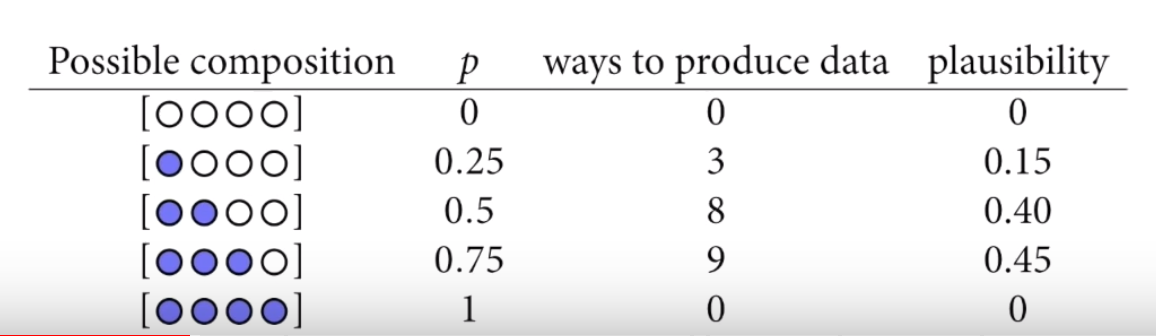

In [6]:
ways = np.array([0, 3, 8, 9, 0])
ways / ways.sum()

array([0.  , 0.15, 0.4 , 0.45, 0.  ])

## Bayesian Updating

What if we wanted to continue refining our plausbility values above? What could we do? Well: draw more marbles of course! 

Then, we just multiple the "old" counts of ways to produce the observed data with the "new" ways to produce the updated data. This is essentially the garden of forking paths at play. See below:

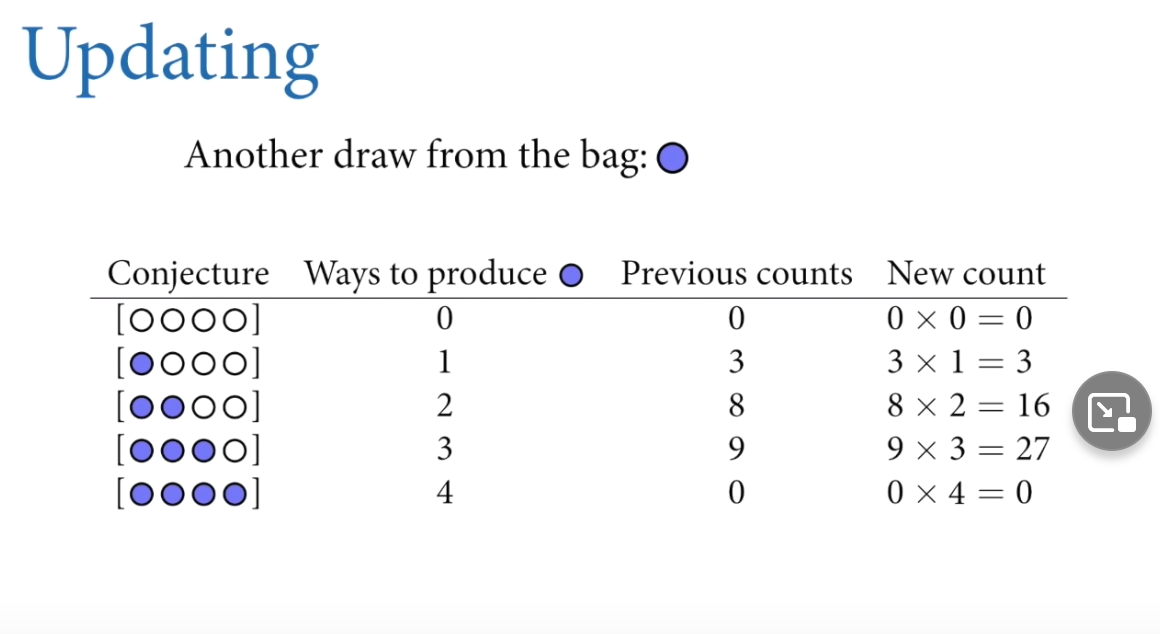

### Rules of Bayesian Updating

    1. State a causal model for how the observations arise, given each possible explanation
    
    2. Count ways data could arise for each explanation (e.g. each bag of marbles)
    
    3. Normalize the plausibilities by summing/dividing

## Some terms: Prior v. Posterior + Density

Prior: The distribution of our parameters (i.e. **relative plausibility**) that we *believe to be true* before observing some data. 

Posterior: The distribution of parameters (i.e. **relative plausibility**) that we believe is true *after* observing some data. AKA: P(distribution|data)

Likelihood: P(data|distribution)

Density: Essentially, it is the relative plausiblity described above. Think of it as the y-axis of any probability distribution. 


## Bayesian Updating: A Graphical Representation with Probability Distributions

Suppose that we're trying to estimate the true proportion of water on the globe and we throw two separate darts at the Earth. One lands in Water, another lands on Land. How do we use these two observations **together** to jointly construct the relative plausibility of different proportions of water? Well...we multiply the "single observation" posteriors:

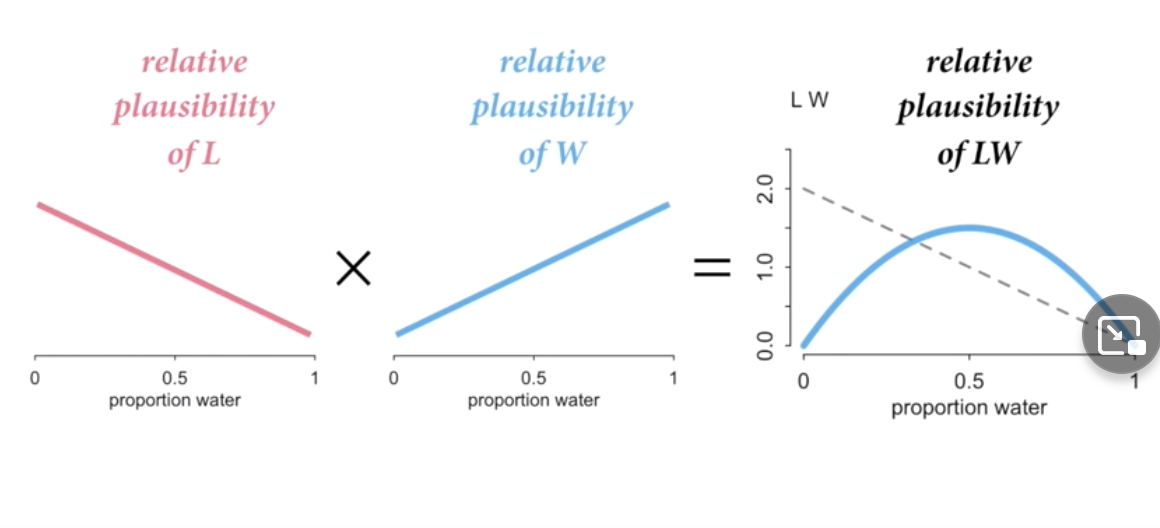

Again: this is just multiplying *numbers of ways*!

**Note:** We typically do this Bayesian updating process using all of our individual measurements together in one big dataset. However, it is important to keep in mind that this *en masse* updating is the end result of lots of individual steps executed sequentially. 

## What are some of the benefits of the Bayesian approach?

    1. No minimum sample size! We can do updating with even 1 singular observation! 
    
    2. Shape of the posterior embodies sample size: The sharper your peaks, the greater your implied sample size is (because more data should ideally refine the posterior). 
    
    3. No point estimates: The estimate IS the posterior curve! Think about all the benefits of not collapsing an entire statistical distribution to one or two numbers (e.g. throwing out uncertainty). That's the essence of Bayesian stats!
    
    4. ~As a corollary to Point 3, intervals take on lesser importance. 

## The Formalities of Bayesian Model Writing

In practice, we write the model in a way that communicates all possible probability assumptions.

**We treat observations (data) and explanations (parameters) as variables. And for each variable, we must say how it is generated (i.e. attribute a generative distribution from where it comes)**

### Modeling with the Globe Tossing Problem

Let's go through this formality with our land/water problem. We have the following:

    1. Data: W and L, the number of land and water observations. These must come from a binomial distribution. The binomial sampling distribution is written out below:
    
    2. Parameters: p, the proportion of water on the globe. 
    

#### Code 2.2

$$Pr(w \mid n, p) =  \frac{n!}{w!(n − w)!} p^w (1 − p)^{n−w}$$


The probability of observing six W’s in nine tosses — below a value of $p=0.5$.

In [4]:
stats.binom.pmf(6, n=9, p=0.5)

0.16406250000000006

#### Code 2.3 and 2.5

Computing the posterior using a grid approximation.

In the book, the following code is not inside a function, but this way it is easier to play with different parameters. The grid is the distribution of possible 

In [18]:
def posterior_grid_approx(grid_points=100, success=4, tosses=9):
    """"""
    # define grid
    p_grid = np.linspace(0, 1, grid_points)

    # define prior
    #prior = np.repeat(5, grid_points)  # uniform
    #prior = (p_grid >= 0.5).astype(int)  # truncated
    prior = np.exp(- 5 * abs(p_grid - 0.5))  # double exp

    # compute likelihood at each point in the grid
    likelihood = stats.binom.pmf(success, tosses, p_grid)

    # compute product of likelihood and prior
    unstd_posterior = likelihood * prior

    # standardize the posterior, so it sums to 1
    posterior = unstd_posterior / unstd_posterior.sum()
    return p_grid, posterior

#### Code 2.3

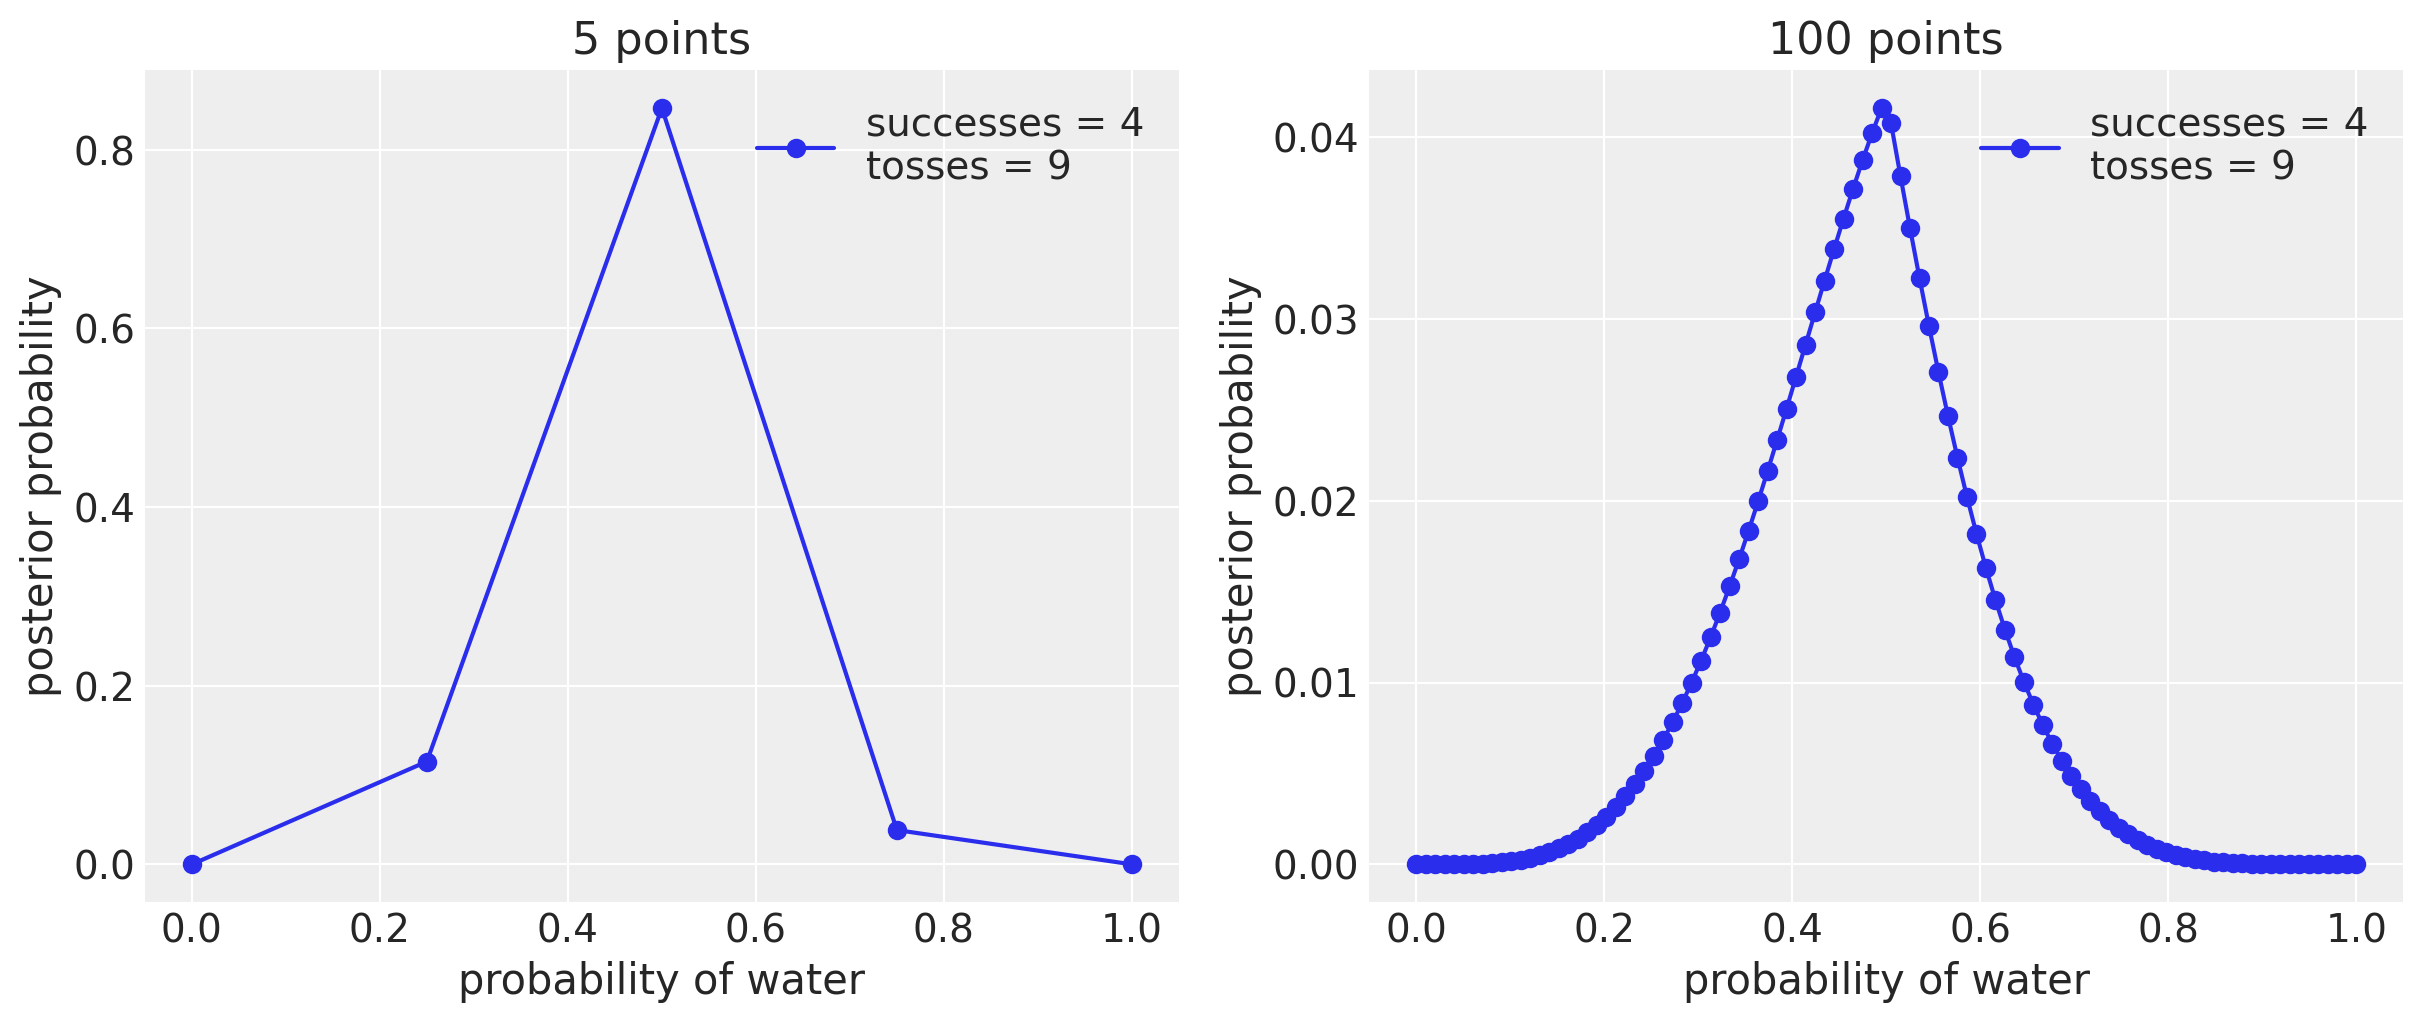

In [19]:
w, n = 4, 9

_, ax = plt.subplots(1, 2, figsize=(12, 5))

points = (5, 100)
for idx, ps in enumerate(points):
    p_grid, posterior = posterior_grid_approx(ps, w, n)
    ax[idx].plot(p_grid, posterior, "o-", label=f"successes = {w}\ntosses = {n}")
    ax[idx].set_xlabel("probability of water")
    ax[idx].set_ylabel("posterior probability")
    ax[idx].set_title(f"{ps} points")
    ax[idx].legend(loc=0)

## Many Ways to Count

We can use: Grid-approximation, quadratic approximation, Markov chain Monte Carlo (MCMC), etc. 

MCMC is a family of methods for sampling from posterior distributions. 

## From Posterior to Prediction.

We have to do *something* with o

Implications of a model depend upon the entire posterior. We can either (a) average any inference over the entire posterior (which requires integral calculus and is a massive pain in the ass) or (b) We can take samples from the posterior. 

#### Code 2.6

Computing the posterior using the quadratic approximation (quad).

In [7]:
np.repeat((0, 1), (3, 6))

array([0, 0, 0, 1, 1, 1, 1, 1, 1])

In [8]:
data = np.repeat((0, 1), (3, 6))
with pm.Model() as normal_approximation:
    p = pm.Uniform("p", 0, 1)  # uniform priors
    w = pm.Binomial("w", n=len(data), p=p, observed=data.sum())  # binomial likelihood
    mean_q = pm.find_MAP()
    std_q = ((1 / pm.find_hessian(mean_q, vars=[p])) ** 0.5)[0]

# display summary of quadratic approximation
print("  Mean, Standard deviation\np {:.2}, {:.2}".format(mean_q["p"], std_q[0]))


  Mean, Standard deviation
p 0.67, 0.16


In [9]:
# Compute the 89% percentile interval
norm = stats.norm(mean_q, std_q)
prob = 0.89
z = stats.norm.ppf([(1 - prob) / 2, (1 + prob) / 2])
pi = mean_q["p"] + std_q * z
print("5.5%, 94.5% \n{:.2}, {:.2}".format(pi[0], pi[1]))

5.5%, 94.5% 
0.42, 0.92


#### Code 2.7

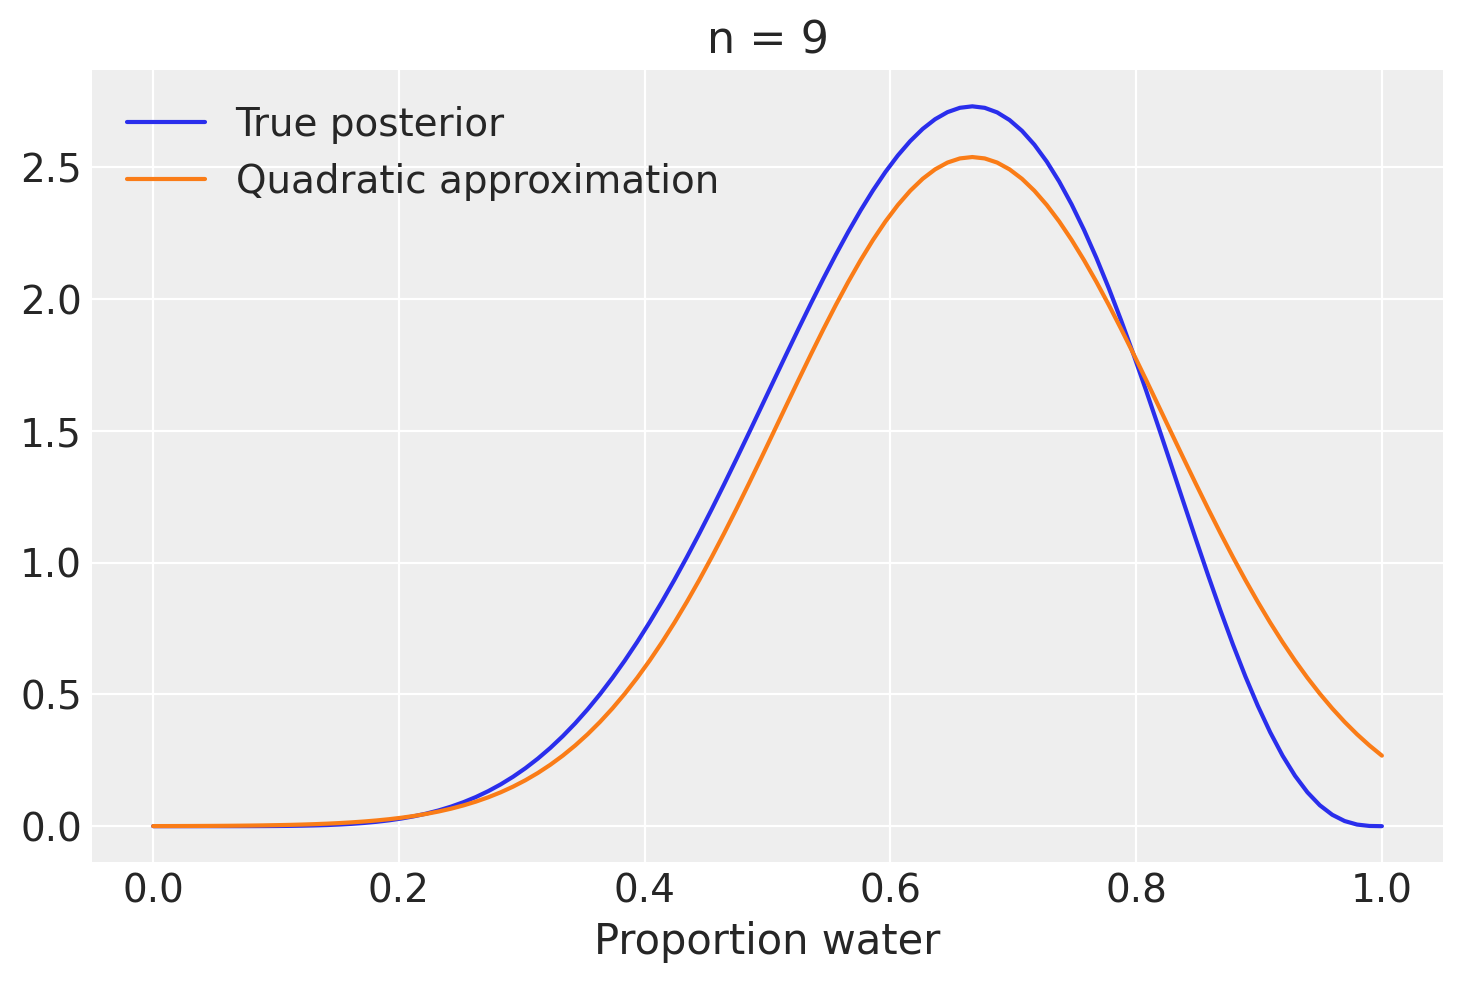

In [10]:
# analytical calculation
w, n = 6, 9
x = np.linspace(0, 1, 100)
plt.plot(x, stats.beta.pdf(x, w + 1, n - w + 1), label="True posterior")

# quadratic approximation
plt.plot(x, stats.norm.pdf(x, mean_q["p"], std_q), label="Quadratic approximation")
plt.legend(loc=0)

plt.title(f"n = {n}")
plt.xlabel("Proportion water");

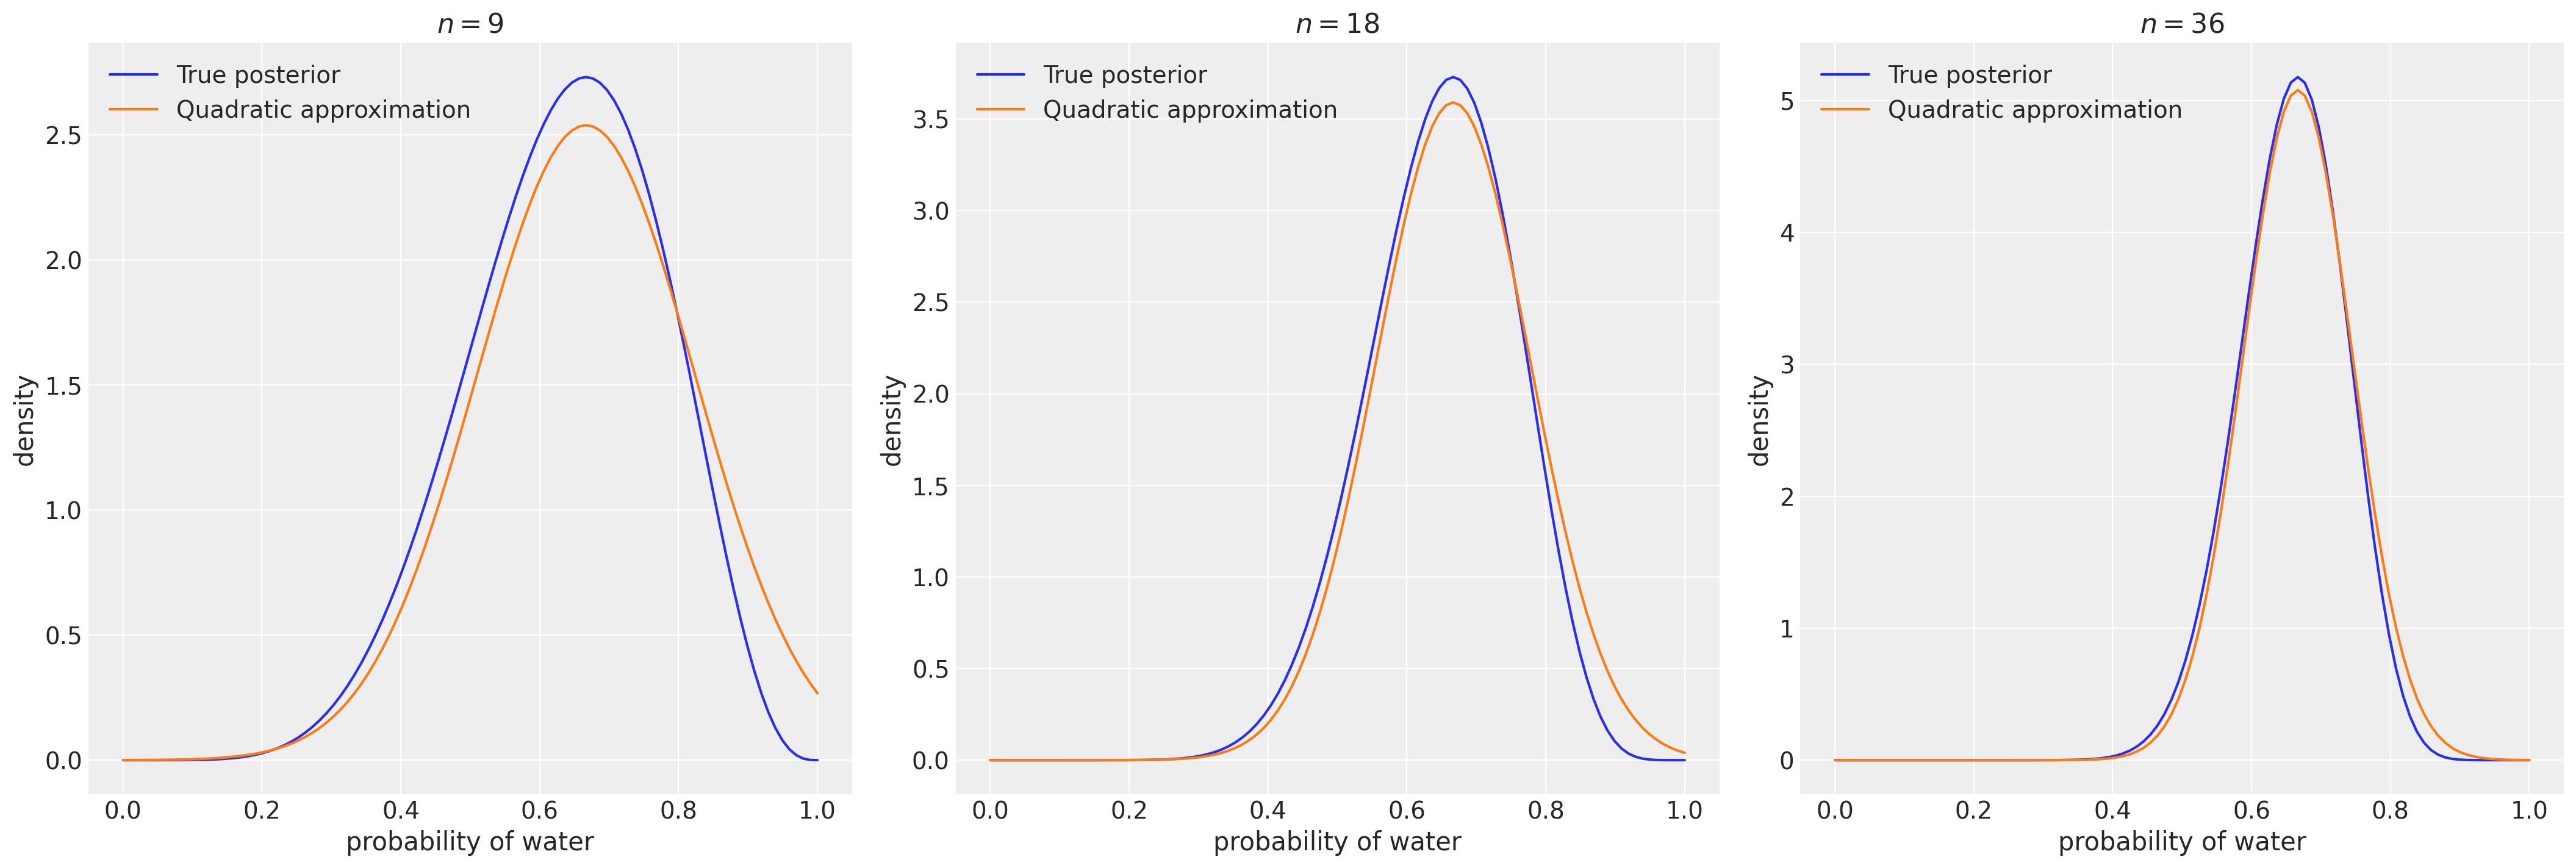

In [11]:
# Figure 2.8
x = np.linspace(0, 1, 100)
w, n = [6, 12, 24], [9, 18, 36]

fig, ax = plt.subplots(1, 3, figsize=(21, 7))

for idx, ps in enumerate(zip(w, n)):
    data = np.repeat((0, 1), (ps[1] - ps[0], ps[0]))
    with pm.Model() as normal_approximation:
        p = pm.Uniform("p", 0, 1)  # uniform priors
        w = pm.Binomial("w", n=len(data), p=p, observed=data.sum())  # binomial likelihood
        mean_q = pm.find_MAP()
        std_q = ((1 / pm.find_hessian(mean_q, vars=[p])) ** 0.5)[0]

    ax[idx].plot(x, stats.beta.pdf(x, ps[0] + 1, ps[1] - ps[0] + 1), label="True posterior")
    ax[idx].plot(x, stats.norm.pdf(x, mean_q["p"], std_q), label="Quadratic approximation")
    ax[idx].set_xlabel("probability of water")
    ax[idx].set_ylabel("density")
    ax[idx].set_title(r"$n={}$".format(ps[1]))
    ax[idx].legend(loc="upper left")

#### Code 2.8

In [12]:
n_samples = 1000
p = np.zeros(n_samples)
p[0] = 0.5
W = 6
L = 3
for i in range(1, n_samples):
    p_new = stats.norm(p[i - 1], 0.1).rvs(1)
    if p_new < 0:
        p_new = -p_new
    if p_new > 1:
        p_new = 2 - p_new
    q0 = stats.binom.pmf(W, n=W + L, p=p[i - 1])
    q1 = stats.binom.pmf(W, n=W + L, p=p_new)
    if stats.uniform.rvs(0, 1) < q1 / q0:
        p[i] = p_new
    else:
        p[i] = p[i - 1]

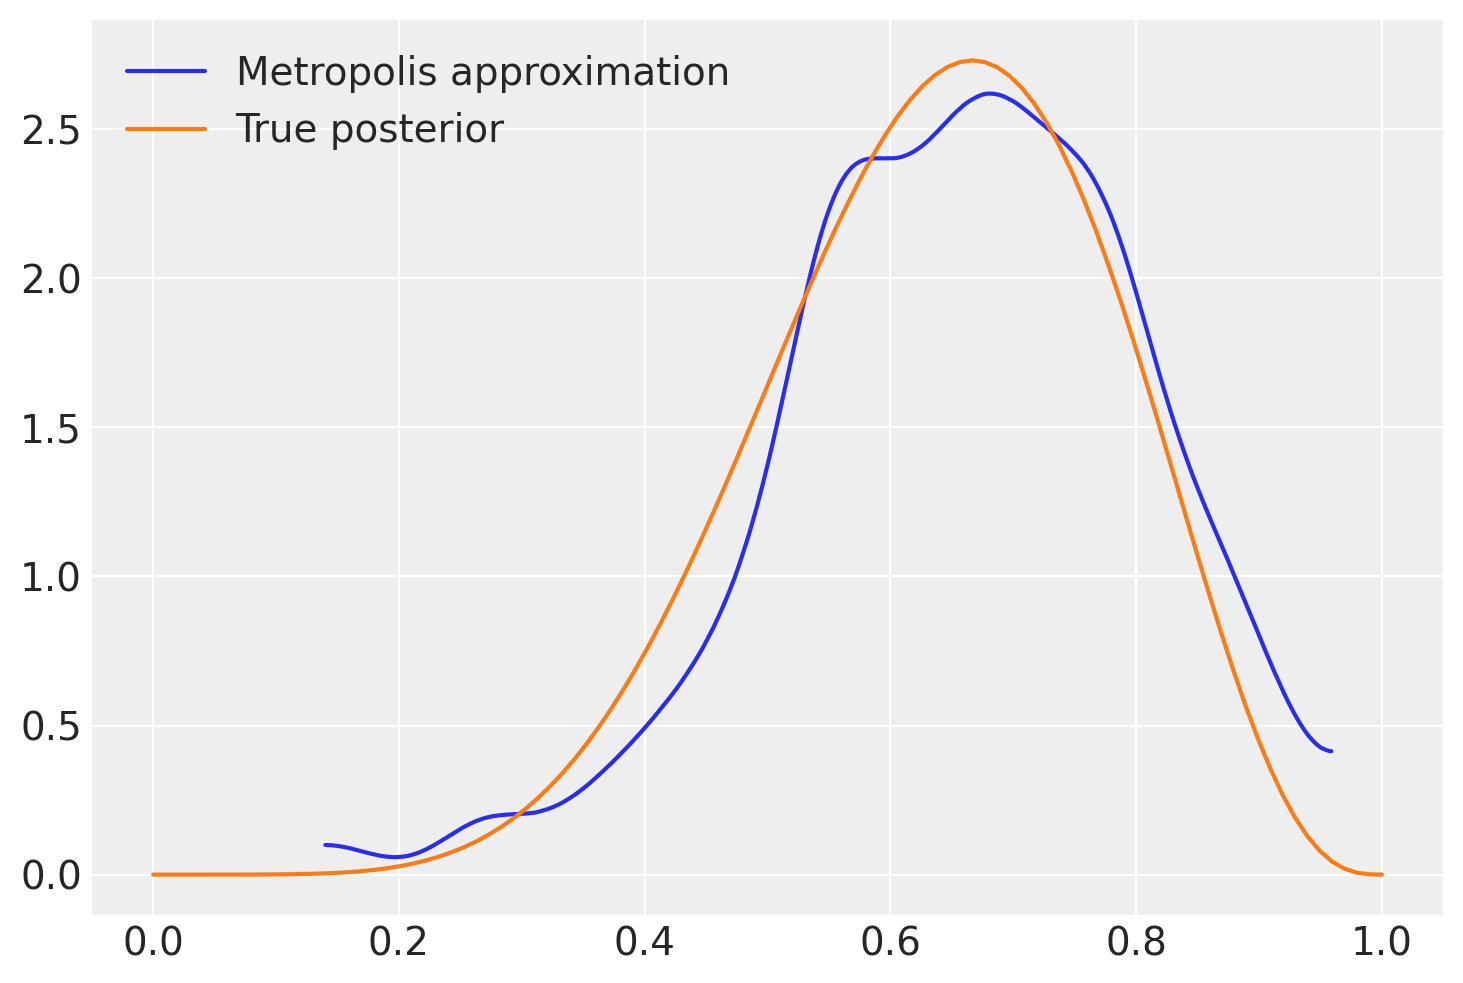

In [13]:
az.plot_kde(p, label="Metropolis approximation")
x = np.linspace(0, 1, 100)
plt.plot(x, stats.beta.pdf(x, W + 1, L + 1), "C1", label="True posterior")
plt.legend();

In [14]:
%watermark -n -u -v -iv -w

Last updated: Sun Dec 20 2020

Python implementation: CPython
Python version       : 3.8.5
IPython version      : 7.19.0

arviz     : 0.10.0
pymc3     : 3.9.3
numpy     : 1.19.4
matplotlib: 3.3.3
scipy     : 1.5.4

Watermark: 2.1.0

